# Cross-Lingual Cultural Analysis of Fine-Tuned Fiction Models
## Comparing English (Mistral-7B) and Japanese (Rinna / Tiny-Aya / LLM-JP) Models

This notebook implements the evaluation pipeline for analyzing cultural bias and linguistic differences
in LLM-generated fiction across English and Japanese models.

### Models Compared
| Model | Language | Parameters | Dataset |
|-------|----------|------------|---------|
| Mistral-7B-Instruct-v0.3 | English | 7B | Project Gutenberg |
| rinna-japanese-gpt-neox-3.6b | Japanese | 3.6B | ParallelFiction-Ja_En-100k |
| CohereLabs/tiny-aya-water | Japanese | 3B | Syosetu711K |
| llm-jp/llm-jp-3-3.7b-instruct | Japanese | 3.7B | Syosetu711K |

### Evaluation Metrics
1. **Structural Metrics**: Story length, TTR, repetition, entropy
2. **Syntactic Analysis**: POS distribution, pronoun-to-noun ratio (SVO vs SOV)
3. **Sentiment Analysis**: Cross-lingual sentiment variance
4. **Cultural Probing**: Cultural Default Rate — measuring Western vs Japanese norm defaults
5. **Narrative Structure**: Kishōtenketsu hypothesis testing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import re
import math
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('figures', exist_ok=True)

matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']

## 1. Data Loading

In [2]:
#=============================================================================
#           FILE PATHS — Matches the repo directory structure
#=============================================================================

#Rinna
RINNA_BEFORE_PATH = "./rinna-jp-model/generated_before.csv"
RINNA_AFTER_PATH = "./rinna-jp-model/generated_stories.csv"

#Tiny-Aya
#baseline
TINY_AYA_BEFORE = "./tiny_aya/generated_before_llm_jp.csv"
TINY_AYA_SHOWCASE_BEFORE = "./tiny_aya/cultural_showcase_before_llm_jp.csv"
#after LoRA
TINY_AYA_AFTER = "./tiny_aya/generated_stories_llm_jp.csv"
TINY_AYA_SHOWCASE_AFTER = "./tiny_aya/cultural_showcase_tiny.csv"

#LLM-JP
#baseline
LLM_JP_BEFORE = "./llm-jp-fiction/generated_before_llm_jp.csv"
LLM_JP_SHOWCASE_BEFORE = "./llm-jp-fiction/cultural_showcase_before_llm_jp.csv"
#after LoRA
LLM_JP_AFTER = "./llm-jp-fiction/generated_stories_llm_jp.csv"
LLM_JP_SHOWCASE_AFTER = "./llm-jp-fiction/cultural_showcase_llm_jp.csv"

#Mistral
#v1.4 is the latest; base folder CSVs are pre-FT baseline from older runs
MISTRAL_BEFORE_PATH = "./mistral7b/generated_before.csv"
MISTRAL_AFTER_PATH  = "./mistral7b/v1.4/generated_stories.csv"


In [3]:
#LOAD DATA — Gracefully handle missing files

def safe_load(path, label):
    #Load CSV if it exists, otherwise return None with a warning.
    if path is None:
        print(f"  [{label}] Path not set — skipping")
        return None
    try:
        df = pd.read_csv(path)
        print(f"  [{label}] Loaded {len(df)} rows from {path}")
        return df
    except FileNotFoundError:
        print(f"  [{label}] File not found: {path} — skipping")
        return None

#Rinna
rinna_before = safe_load(RINNA_BEFORE_PATH, "Rinna before")
rinna_after  = safe_load(RINNA_AFTER_PATH,  "Rinna after")

#Tiny-aya
tiny_aya_before = safe_load(TINY_AYA_BEFORE, "Tiny-Aya before")
tiny_aya_after  = safe_load(TINY_AYA_AFTER,  "Tiny-Aya after")
tiny_aya_show_before = safe_load(TINY_AYA_SHOWCASE_BEFORE, "Tiny-Aya showcase before")
tiny_aya_show_after  = safe_load(TINY_AYA_SHOWCASE_AFTER,  "Tiny-Aya showcase after")

#LLM-JP
llm_jp_before = safe_load(LLM_JP_BEFORE, "LLM-JP before")
llm_jp_after  = safe_load(LLM_JP_AFTER,  "LLM-JP after")
llm_jp_show_before = safe_load(LLM_JP_SHOWCASE_BEFORE, "LLM-JP showcase before")
llm_jp_show_after  = safe_load(LLM_JP_SHOWCASE_AFTER,  "LLM-JP showcase after")

#Mistral EN
en_before = safe_load(MISTRAL_BEFORE_PATH, "Mistral before")
en_after  = safe_load(MISTRAL_AFTER_PATH,  "Mistral after")

print("\nData loading complete.")


  [Rinna before] Loaded 200 rows from ./rinna-jp-model/generated_before.csv
  [Rinna after] Loaded 80 rows from ./rinna-jp-model/generated_stories.csv
  [Tiny-Aya before] Loaded 100 rows from ./tiny_aya/generated_before_llm_jp.csv
  [Tiny-Aya after] Loaded 100 rows from ./tiny_aya/generated_stories_llm_jp.csv
  [Tiny-Aya showcase before] Loaded 2 rows from ./tiny_aya/cultural_showcase_before_llm_jp.csv
  [Tiny-Aya showcase after] Loaded 2 rows from ./tiny_aya/cultural_showcase_tiny.csv
  [LLM-JP before] Loaded 100 rows from ./llm-jp-fiction/generated_before_llm_jp.csv
  [LLM-JP after] Loaded 100 rows from ./llm-jp-fiction/generated_stories_llm_jp.csv
  [LLM-JP showcase before] Loaded 2 rows from ./llm-jp-fiction/cultural_showcase_before_llm_jp.csv
  [LLM-JP showcase after] Loaded 2 rows from ./llm-jp-fiction/cultural_showcase_llm_jp.csv
  [Mistral before] Loaded 20 rows from ./mistral7b/generated_before.csv
  [Mistral after] Loaded 80 rows from ./mistral7b/v1.4/generated_stories.csv

D

In [4]:
#CLEAN RINNA DATA
#The Rinna model outputs include the prompt (ユーザー: ... システム:)

def clean_rinna_story(text):
    text = str(text)
    #Split on システム: and take everything after
    if 'システム:' in text:
        text = text.split('システム:', 1)[1]
    elif 'システム：' in text:  # fullwidth colon
        text = text.split('システム：', 1)[1]
    #Replace <NL> tokens with actual newlines
    text = text.replace('<NL>', '\n')
    return text.strip()

if rinna_before is not None:
    rinna_before['story_clean'] = rinna_before['story'].apply(clean_rinna_story)
if rinna_after is not None:
    rinna_after['story_clean'] = rinna_after['story'].apply(clean_rinna_story)

## 2. Structural Metrics

Measure basic text properties: length, vocabulary richness, repetition, and entropy.
These establish baseline differences between models and languages.

In [5]:
#METRIC FUNCTIONS
def char_count(text):
    return len(str(text))

def word_count(text):
    #Word count
    return len(str(text).split())

def type_token_ratio(texts):
    #TTR for English
    words = []
    for t in texts:
        words += re.findall(r'\b\w+\b', str(t).lower())
    return len(set(words)) / len(words) if words else 0

def char_type_token_ratio(texts):
    #Character-level TTR — better for Japanese
    all_chars = []
    for t in texts:
        all_chars += list(str(t))
    return len(set(all_chars)) / len(all_chars) if all_chars else 0

def repetition_score(text):
    #Fraction of words that appear more than once
    words = str(text).split()
    counts = Counter(words)
    repeated = sum(v for v in counts.values() if v > 1)
    return repeated / len(words) if words else 0

def entropy(texts):
    #Character-level Shannon entropy
    tokens = []
    for t in texts:
        tokens += list(str(t))
    counts = Counter(tokens)
    total = sum(counts.values())
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

def avg_sentence_length(texts, delimiter):
    #Average sentence length in characters
    lengths = []
    for t in texts:
        sentences = str(t).split(delimiter)
        sentences = [s for s in sentences if len(s.strip()) > 0]
        lengths += [len(s) for s in sentences]
    return np.mean(lengths) if lengths else 0

In [6]:
#COMPUTE METRICS FOR ALL AVAILABLE MODELS

results = {}

def compute_jp_metrics(stories, label):
    return {
        'Avg Char Count': stories.apply(char_count).mean(),
        'Char TTR': char_type_token_ratio(stories),
        'Avg Repetition': stories.apply(repetition_score).mean(),
        'Char Entropy': entropy(stories),
        'Avg Sentence Len': avg_sentence_length(stories, '。'),
        'N Stories': len(stories),
    }

def compute_en_metrics(stories, label):
    return {
        'Avg Char Count': stories.apply(char_count).mean(),
        'Avg Word Count': stories.apply(word_count).mean(),
        'Word TTR': type_token_ratio(stories),
        'Char TTR': char_type_token_ratio(stories),
        'Avg Repetition': stories.apply(repetition_score).mean(),
        'Char Entropy': entropy(stories),
        'Avg Sentence Len': avg_sentence_length(stories, '.'),
        'N Stories': len(stories),
    }

#Rinna
if rinna_before is not None:
    results['Rinna (before)'] = compute_jp_metrics(rinna_before['story_clean'], 'Rinna before')
if rinna_after is not None:
    results['Rinna (after)'] = compute_jp_metrics(rinna_after['story_clean'], 'Rinna after')

#Tiny-Aya
if tiny_aya_before is not None:
    results['Tiny-Aya (before)'] = compute_jp_metrics(tiny_aya_before['story'], 'Tiny-Aya before')
if tiny_aya_after is not None:
    results['Tiny-Aya (after)'] = compute_jp_metrics(tiny_aya_after['story'], 'Tiny-Aya after')

#LLM-JP
if llm_jp_before is not None:
    results['LLM-JP (before)'] = compute_jp_metrics(llm_jp_before['story'], 'LLM-JP before')
if llm_jp_after is not None:
    results['LLM-JP (after)'] = compute_jp_metrics(llm_jp_after['story'], 'LLM-JP after')

#Mistral EN
if en_before is not None:
    results['Mistral (before)'] = compute_en_metrics(en_before['story'], 'Mistral before')
if en_after is not None:
    results['Mistral (after)'] = compute_en_metrics(en_after['story'], 'Mistral after')

#Display results table
metrics_df = pd.DataFrame(results).T
print("\n=== Structural Metrics Summary ===")
print(metrics_df.to_string(float_format='{:.4f}'.format))



=== Structural Metrics Summary ===
                   Avg Char Count  Char TTR  Avg Repetition  Char Entropy  Avg Sentence Len  N Stories  Avg Word Count  Word TTR
Rinna (before)           163.3550    0.0216          0.0387        7.1677           73.3318   200.0000             NaN       NaN
Rinna (after)            636.5250    0.0198          0.2086        7.6057           52.1942    80.0000             NaN       NaN
Tiny-Aya (before)        413.6000    0.0314          0.0000        7.4914           31.7672   100.0000             NaN       NaN
Tiny-Aya (after)         487.5300    0.0292          0.0241        7.8397           32.8455   100.0000             NaN       NaN
LLM-JP (before)          406.3700    0.0313          0.0000        7.5059           30.7936   100.0000             NaN       NaN
LLM-JP (after)           481.7400    0.0278          0.0000        7.4691           30.8269   100.0000             NaN       NaN
Mistral (before)        1104.1000    0.0030          0.3120  

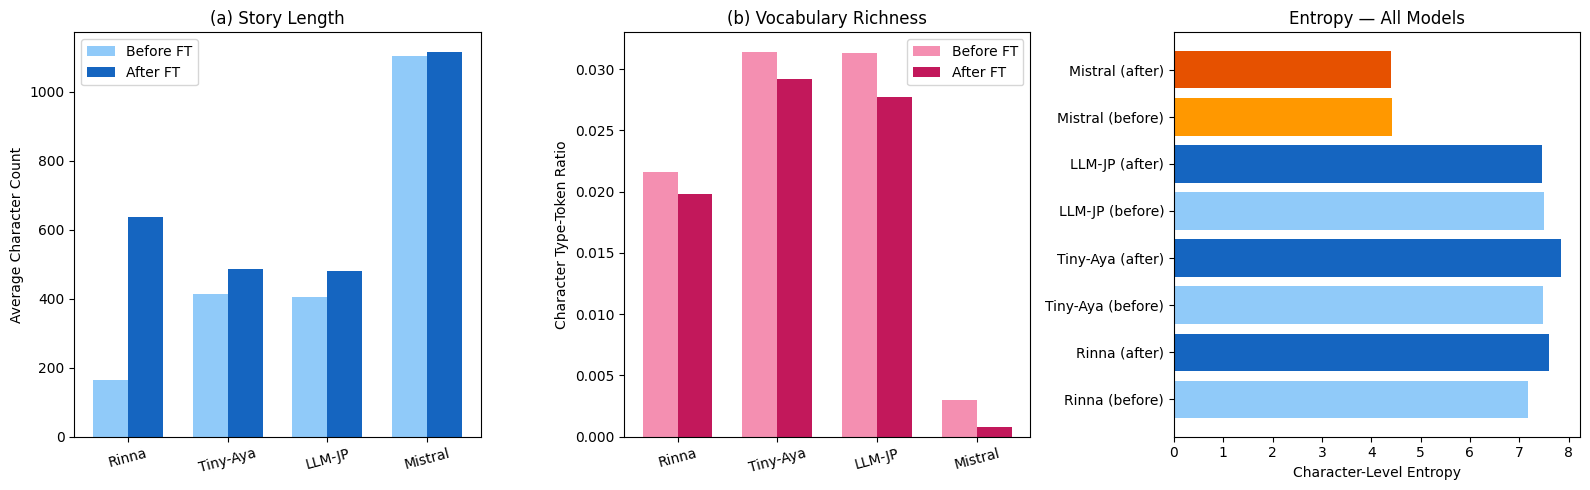

Saved: fig1_structural_metrics.png


In [7]:
#FIGURE 1: Structural Metrics — Before vs After Fine-Tuning

#Group models into before/after pairs for comparison
pairs = []
for base in ['Rinna', 'Tiny-Aya', 'LLM-JP', 'Mistral']:
    before_key = f'{base} (before)'
    after_key = f'{base} (after)'
    if before_key in results and after_key in results:
        pairs.append((base, before_key, after_key))

if pairs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    x = np.arange(len(pairs))
    width = 0.35
    
    #1 Character count before/after
    before_vals = [results[p[1]]['Avg Char Count'] for p in pairs]
    after_vals  = [results[p[2]]['Avg Char Count'] for p in pairs]
    axes[0].bar(x - width/2, before_vals, width, label='Before FT', color='#90CAF9')
    axes[0].bar(x + width/2, after_vals, width, label='After FT', color='#1565C0')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([p[0] for p in pairs], rotation=15)
    axes[0].set_ylabel('Average Character Count')
    axes[0].set_title('(a) Story Length')
    axes[0].legend()
    
    #2: Char TTR before/after
    before_vals = [results[p[1]].get('Char TTR', 0) for p in pairs]
    after_vals  = [results[p[2]].get('Char TTR', 0) for p in pairs]
    axes[1].bar(x - width/2, before_vals, width, label='Before FT', color='#F48FB1')
    axes[1].bar(x + width/2, after_vals, width, label='After FT', color='#C2185B')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([p[0] for p in pairs], rotation=15)
    axes[1].set_ylabel('Character Type-Token Ratio')
    axes[1].set_title('(b) Vocabulary Richness')
    axes[1].legend()
    
    #3: Entropy comparison
    all_models = list(results.keys())
    vals = [results[m]['Char Entropy'] for m in all_models]
    colors = []
    for m in all_models:
        if 'Mistral' in m:
            colors.append('#FF9800' if 'before' in m else '#E65100')
        elif 'before' in m:
            colors.append('#90CAF9')
        else:
            colors.append('#1565C0')
    axes[2].barh(all_models, vals, color=colors)
    axes[2].set_xlabel('Character-Level Entropy')
    axes[2].set_title('Entropy — All Models')
    
    plt.tight_layout()
    #plt.savefig('figures/fig1_structural_metrics.pdf', bbox_inches='tight', dpi=150)
    plt.savefig('figures/fig1_structural_metrics.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: fig1_structural_metrics.png")
else:
    print("Need at least one before/after pair to plot. Check data loading.")


## 3. Syntactic Analysis — POS Distribution

English is SVO with frequent pronoun use; Japanese is SOV with frequent pronoun drop.
The pronoun-to-noun ratio captures this structural difference quantitatively.

This analysis validates that fine-tuned outputs preserve language-specific syntactic patterns.

In [8]:
#Optional imports - install if needed, 
#the code already doe this, but if you run want to run it before

#!pip install spacy textblob transformers
#!python -m spacy download en_core_web_sm
#!python -m spacy download ja_core_news_sm

In [9]:
#POS DISTRIBUTION
#Requires spacy with en_core_web_sm and ja_core_news_sm
import spacy

def get_pos_distribution(texts, nlp_model, max_docs=50):
    #Count POS tags and return normalized distribution + raw counts
    pos_counts = {'PRON': 0, 'NOUN': 0, 'VERB': 0, 'ADP': 0, 'ADJ': 0}
    total_tokens = 0
    
    text_list = [str(t)[:2000] for t in texts[:max_docs]]
    
    for doc in nlp_model.pipe(text_list, batch_size=20):
        for token in doc:
            if token.pos_ in pos_counts:
                pos_counts[token.pos_] += 1
            total_tokens += 1
    
    #Normalized
    pos_norm = {k: v / total_tokens if total_tokens > 0 else 0 for k, v in pos_counts.items()}
    return pos_norm, pos_counts, total_tokens

try:
    nlp_en = spacy.load("en_core_web_sm")
    nlp_jp = spacy.load("ja_core_news_sm")
    SPACY_AVAILABLE = True
    print("spaCy models loaded")
except OSError:
    SPACY_AVAILABLE = False
    print("spaCy models not found.")

spaCy models loaded


In [10]:
#RUN POS ANALYSIS

pos_results = {}

if SPACY_AVAILABLE:
    #Japanese after fine-tuning
    if tiny_aya_after is not None:
        pos_norm, _, _ = get_pos_distribution(tiny_aya_after['story'], nlp_jp)
        pos_results['Tiny-Aya (JP)'] = pos_norm
        print(f"Tiny-Aya POS: {pos_norm}")
    
    if llm_jp_after is not None and 'story' in llm_jp_after.columns:
        pos_norm, _, _ = get_pos_distribution(llm_jp_after['story'], nlp_jp)
        pos_results['LLM-JP (JP)'] = pos_norm
        print(f"LLM-JP POS: {pos_norm}")
    
    if rinna_after is not None:
        pos_norm, _, _ = get_pos_distribution(rinna_after['story_clean'], nlp_jp)
        pos_results['Rinna (JP)'] = pos_norm
        print(f"Rinna POS: {pos_norm}")
    
    #English after fine-tuning
    if en_after is not None:
        pos_norm, _, _ = get_pos_distribution(en_after['story'], nlp_en)
        pos_results['Mistral (EN)'] = pos_norm
        print(f"Mistral POS: {pos_norm}")

    #Ratios
    print("\n=== Pronoun-to-Noun Ratio ===")
    for model, pos in pos_results.items():
        ratio = pos['PRON'] / pos['NOUN'] if pos['NOUN'] > 0 else 0
        lang = 'JP' if 'JP' in model else 'EN'
        expected = 'LOW (pronoun drop)' if lang == 'JP' else 'HIGH (explicit pronouns)'
        print(f"  {model}: {ratio:.4f}  (expected: {expected})")


Tiny-Aya POS: {'PRON': 0.020810301099044026, 'NOUN': 0.24770761526955842, 'VERB': 0.12011445665604474, 'ADP': 0.22143461013201535, 'ADJ': 0.026858294855953698}
LLM-JP POS: {'PRON': 0.02453731343283582, 'NOUN': 0.2186865671641791, 'VERB': 0.13444776119402985, 'ADP': 0.21653731343283583, 'ADJ': 0.02871641791044776}
Rinna POS: {'PRON': 0.025359668373567422, 'NOUN': 0.24268471104608633, 'VERB': 0.1141185076810534, 'ADP': 0.20452328700316996, 'ADJ': 0.02487198244330651}
Mistral POS: {'PRON': 0.06485945601746566, 'NOUN': 0.2064040753206586, 'VERB': 0.1139816246702447, 'ADP': 0.11880287455653597, 'ADJ': 0.07832256890748658}

=== Pronoun-to-Noun Ratio ===
  Tiny-Aya (JP): 0.0840  (expected: LOW (pronoun drop))
  LLM-JP (JP): 0.1122  (expected: LOW (pronoun drop))
  Rinna (JP): 0.1045  (expected: LOW (pronoun drop))
  Mistral (EN): 0.3142  (expected: HIGH (explicit pronouns))


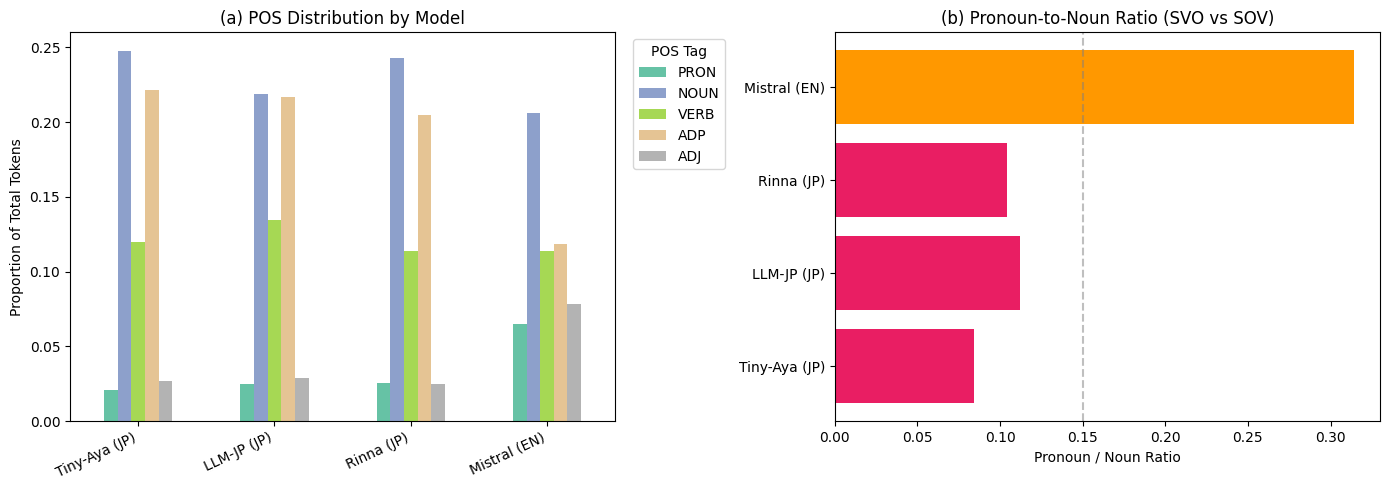

Saved: fig2_pos_distribution.png


In [11]:
#FIGURE 2: POS Distribution Comparison
if pos_results:
    pos_df = pd.DataFrame(pos_results).T
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    #1: POS distribution stacked bar
    pos_df.plot(kind='bar', ax=axes[0], colormap='Set2')
    axes[0].set_title('(a) POS Distribution by Model')
    axes[0].set_ylabel('Proportion of Total Tokens')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha='right')
    axes[0].legend(title='POS Tag', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    #2: Pronoun-to-Noun ratio
    ratios = {m: pos['PRON'] / pos['NOUN'] if pos['NOUN'] > 0 else 0
              for m, pos in pos_results.items()}
    colors = ['#E91E63' if 'JP' in m else '#FF9800' for m in ratios]
    axes[1].barh(list(ratios.keys()), list(ratios.values()), color=colors)
    axes[1].set_xlabel('Pronoun / Noun Ratio')
    axes[1].set_title('(b) Pronoun-to-Noun Ratio (SVO vs SOV)')
    axes[1].axvline(x=0.15, color='gray', linestyle='--', alpha=0.5, label='Approx boundary')
    
    plt.tight_layout()
    #plt.savefig('figures/fig2_pos_distribution.pdf', bbox_inches='tight', dpi=150)
    plt.savefig('figures/fig2_pos_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: fig2_pos_distribution.png")
else:
    print("no spaCy results available.")

## 4. Cross-Lingual Sentiment Variance

Using a multilingual sentiment model to compare the emotional range of generated stories.
Higher variance suggests the model produces a broader emotional spectrum.

Based on the methodology from Rooein et al. (EMNLP 2025), which uses attribute-level
analysis of generated stories to identify cultural and topic bias.

In [12]:
#SENTIMENT ANALYSIS — multilingual model
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

def get_sentiment_stats(texts, label=""):
    """Compute sentiment scores and statistics for a corpus."""
    valid_texts = [str(t)[:512] for t in texts if str(t).strip()]
    results = sentiment_pipeline(valid_texts, batch_size=16, truncation=True, max_length=512)
    scores = [int(res['label'].split()[0]) for res in results]
    
    variance = np.var(scores)
    std_dev = np.std(scores)
    mean_score = np.mean(scores)
    
    print(f"  {label}: mean={mean_score:.3f}, var={variance:.4f}, std={std_dev:.4f}, n={len(scores)}")
    return scores, variance, std_dev, mean_score

print("Running sentiment analysis...")
sentiment_results = {}

#Tiny-Aya before/after
if tiny_aya_before is not None:
    s, v, sd, m = get_sentiment_stats(tiny_aya_before['story'], "Tiny-Aya (before)")
    sentiment_results['Tiny-Aya (before)'] = {'scores': s, 'var': v, 'std': sd, 'mean': m}
if tiny_aya_after is not None:
    s, v, sd, m = get_sentiment_stats(tiny_aya_after['story'], "Tiny-Aya (after)")
    sentiment_results['Tiny-Aya (after)'] = {'scores': s, 'var': v, 'std': sd, 'mean': m}

#LLM-JP before/after
if llm_jp_before is not None:
    s, v, sd, m = get_sentiment_stats(llm_jp_before['story'], "LLM-JP (before)")
    sentiment_results['LLM-JP (before)'] = {'scores': s, 'var': v, 'std': sd, 'mean': m}
if llm_jp_after is not None:
    s, v, sd, m = get_sentiment_stats(llm_jp_after['story'], "LLM-JP (after)")
    sentiment_results['LLM-JP (after)'] = {'scores': s, 'var': v, 'std': sd, 'mean': m}

#Rinna after (before is too incoherent for meaningful sentiment)
if rinna_after is not None:
    s, v, sd, m = get_sentiment_stats(rinna_after['story_clean'], "Rinna (after)")
    sentiment_results['Rinna (after)'] = {'scores': s, 'var': v, 'std': sd, 'mean': m}

#Mistral EN
if en_before is not None:
    s, v, sd, m = get_sentiment_stats(en_before['story'], "Mistral (before)")
    sentiment_results['Mistral (before)'] = {'scores': s, 'var': v, 'std': sd, 'mean': m}
if en_after is not None:
    s, v, sd, m = get_sentiment_stats(en_after['story'], "Mistral (after)")
    sentiment_results['Mistral (after)'] = {'scores': s, 'var': v, 'std': sd, 'mean': m}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running sentiment analysis...
  Tiny-Aya (before): mean=3.870, var=0.4931, std=0.7022, n=100
  Tiny-Aya (after): mean=3.990, var=0.0499, std=0.2234, n=100
  LLM-JP (before): mean=3.910, var=0.2619, std=0.5118, n=100
  LLM-JP (after): mean=3.930, var=0.4451, std=0.6672, n=100
  Rinna (after): mean=4.075, var=0.1444, std=0.3800, n=80
  Mistral (before): mean=4.000, var=0.0000, std=0.0000, n=20
  Mistral (after): mean=3.975, var=0.0244, std=0.1561, n=80


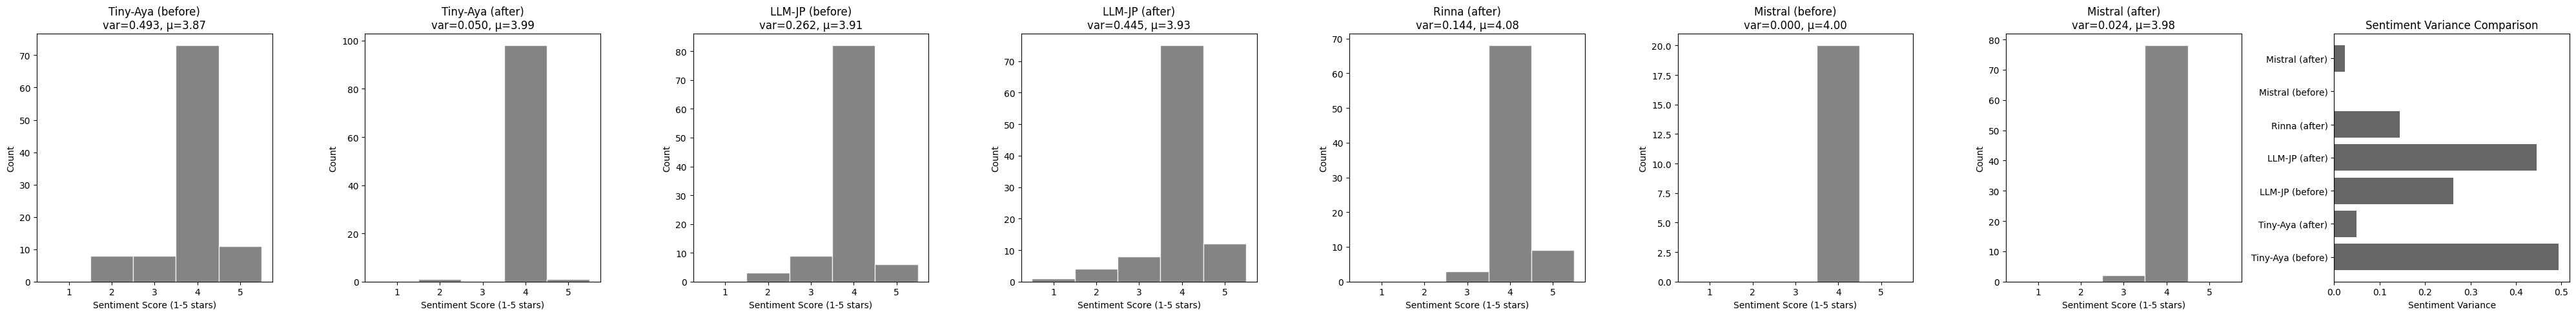

Saved: fig3_sentiment.png


In [13]:
#FIGURE 3: Sentiment Distribution

if sentiment_results:
    n_models = len(sentiment_results)
    fig, axes = plt.subplots(1, n_models + 1, figsize=(5 * (n_models + 1), 5))
    if n_models + 1 == 1:
        axes = [axes]
    
    colors_map = {
        'Tiny-Aya (JP)': '#E91E63',
        'Rinna (JP)': '#2196F3',
        'Mistral-7B (EN)': '#FF9800',
    }
    
    # Individual histograms
    for i, (model, data) in enumerate(sentiment_results.items()):
        c = colors_map.get(model, '#666')
        axes[i].hist(data['scores'], bins=[0.5,1.5,2.5,3.5,4.5,5.5],
                     color=c, alpha=0.8, edgecolor='white')
        axes[i].set_xlabel('Sentiment Score (1-5 stars)')
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'{model}\nvar={data["var"]:.3f}, μ={data["mean"]:.2f}')
        axes[i].set_xticks([1, 2, 3, 4, 5])
    
    # Summary bar chart: variance comparison
    ax = axes[-1]
    models = list(sentiment_results.keys())
    variances = [sentiment_results[m]['var'] for m in models]
    bar_colors = [colors_map.get(m, '#666') for m in models]
    ax.barh(models, variances, color=bar_colors)
    ax.set_xlabel('Sentiment Variance')
    ax.set_title('Sentiment Variance Comparison')
    
    plt.tight_layout()
    #plt.savefig('figures/fig3_sentiment.pdf', bbox_inches='tight', dpi=150)
    plt.savefig('figures/fig3_sentiment.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: fig3_sentiment.png")

## 5. Cultural Default Rate (Novel Metric)

This is our proposed evaluation metric for measuring Western bias in LLM fiction output.

**Definition**: Given a culturally ambiguous prompt (e.g., "a story about a harvest festival with
pumpkins"), we measure whether the model defaults to Western cultural norms (orange pumpkin,
Halloween, jack-o-lanterns) or Japanese cultural norms (green kabocha, autumn festivals, nimono).

This builds on https://arxiv.org/abs/2504.10191

**Metric**: Cultural Default Rate (CDR) = proportion of stories that contain Western-default markers
vs. Japanese-native markers for each prompt category.

In [14]:
#CULTURAL MARKER WORDLISTS

#Each category has Western-default markers and Japanese-native markers
#A model trained on Japanese fiction should produce more JP markers

CULTURAL_MARKERS = {
    'pumpkin': {
        'western': ['オレンジ', 'ジャックオランタン', 'ジャック・オ・ランタン',
                     'ランタン', 'ハロウィン', 'カービング', '彫り'],
        'japanese': ['緑', '煮物', 'かぼちゃの煮物', '収穫', '畑',
                     '甘い', 'ほくほく', '和食', '精進料理'],
    },
    'halloween': {
        'western': ['トリック・オア・トリート', 'トリックオアトリート',
                     'キャンディ', 'コスチューム', '仮装パーティー',
                     'ゾンビ', 'ゴースト', 'モンスター'],
        'japanese': ['お盆', '百鬼夜行', '妖怪', '幽霊', '怪談',
                     '提灯', '灯篭', '神社', '祭り'],
    },
    'breakfast': {
        'western': ['シリアル', 'トースト', 'パンケーキ', 'ベーコン',
                     'エッグ', 'コーヒー', 'オレンジジュース'],
        'japanese': ['味噌汁', 'ご飯', '納豆', '焼き魚', '漬物',
                     '卵焼き', '海苔', '箸', 'お茶'],
    },
    'school': {
        'western': ['スクールバス', 'ロッカー', 'プロム', 'チアリーダー',
                     'フットボール', 'カフェテリア'],
        'japanese': ['制服', '部活', '弁当', '桜', '教室', '先輩',
                     '後輩', '体育祭', '文化祭', '屋上'],
    },
    'spring': {
        'western': ['イースター', 'バニー', 'エッグハント', 'チューリップ'],
        'japanese': ['桜', '花見', '入学式', '新学期', '春風',
                     '卒業', '梅'],
    },
}

def score_cultural_markers(text, markers):
    #Count Western vs Japanese marker hits in a story
    text = str(text)
    western_hits = sum(1 for m in markers['western'] if m in text)
    japanese_hits = sum(1 for m in markers['japanese'] if m in text)
    return western_hits, japanese_hits

print("Cultural marker wordlists defined.")
print(f"Categories: {list(CULTURAL_MARKERS.keys())}")

Cultural marker wordlists defined.
Categories: ['pumpkin', 'halloween', 'breakfast', 'school', 'spring']


In [15]:
#Before vs After Fine-Tuning

def compute_cultural_scores(df, label):
    #Score a corpus against cultural marker wordlists
    if df is None:
        return None
    
    scores = []
    for _, row in df.iterrows():
        prompt_id = row.get('prompt_id', '')
        if prompt_id not in CULTURAL_MARKERS:
            continue
        
        markers = CULTURAL_MARKERS[prompt_id]
        w_hits, j_hits = score_cultural_markers(row['story'], markers)
        total_hits = w_hits + j_hits
        
        scores.append({
            'prompt_id': prompt_id,
            'western_hits': w_hits,
            'japanese_hits': j_hits,
            'total_hits': total_hits,
            'jp_ratio': j_hits / total_hits if total_hits > 0 else 0.5,
        })
    
    if not scores:
        return None
    
    cdf = pd.DataFrame(scores)
    jp_total = cdf['japanese_hits'].sum()
    w_total = cdf['western_hits'].sum()
    overall = jp_total + w_total
    cdr = jp_total / overall if overall > 0 else 0.5
    
    print(f"  {label}: JP={jp_total}, W={w_total}, CDR={cdr:.1%}  ({'JP-default' if cdr > 0.5 else 'W-default'})")
    return cdf, cdr

print("=== Cultural Default Rate (CDR) ===\n")
cultural_results = {}

for name, df in [
    ('Tiny-Aya (before)', tiny_aya_before),
    ('Tiny-Aya (after)',  tiny_aya_after),
    ('LLM-JP (before)',   llm_jp_before),
    ('LLM-JP (after)',    llm_jp_after),
]:
    result = compute_cultural_scores(df, name)
    if result is not None:
        cultural_results[name] = result

# Per-category breakdown for the best model pair
print("\n--- Per-Category Breakdown ---")
for name, (cdf, cdr) in cultural_results.items():
    print(f"\n  {name} (overall CDR: {cdr:.1%})")
    print(f"  {'Category':<20} {'JP':>6} {'W':>6} {'Ratio':>8}")
    print(f"  {'-'*42}")
    for pid in CULTURAL_MARKERS:
        subset = cdf[cdf['prompt_id'] == pid]
        if len(subset) == 0:
            continue
        jp = subset['japanese_hits'].sum()
        w = subset['western_hits'].sum()
        r = jp / (jp + w) if (jp + w) > 0 else 0.5
        print(f"  {pid:<20} {jp:>6} {w:>6} {r:>8.1%}")


=== Cultural Default Rate (CDR) ===

  Tiny-Aya (before): JP=42, W=14, CDR=75.0%  (JP-default)
  Tiny-Aya (after): JP=47, W=15, CDR=75.8%  (JP-default)
  LLM-JP (before): JP=53, W=19, CDR=73.6%  (JP-default)
  LLM-JP (after): JP=44, W=21, CDR=67.7%  (JP-default)

--- Per-Category Breakdown ---

  Tiny-Aya (before) (overall CDR: 75.0%)
  Category                 JP      W    Ratio
  ------------------------------------------
  pumpkin                  12      1    92.3%
  halloween                 4      5    44.4%
  breakfast                 2      8    20.0%
  school                   12      0   100.0%
  spring                   12      0   100.0%

  Tiny-Aya (after) (overall CDR: 75.8%)
  Category                 JP      W    Ratio
  ------------------------------------------
  pumpkin                  23      1    95.8%
  halloween                 5      0   100.0%
  breakfast                 0     14     0.0%
  school                   10      0   100.0%
  spring                  

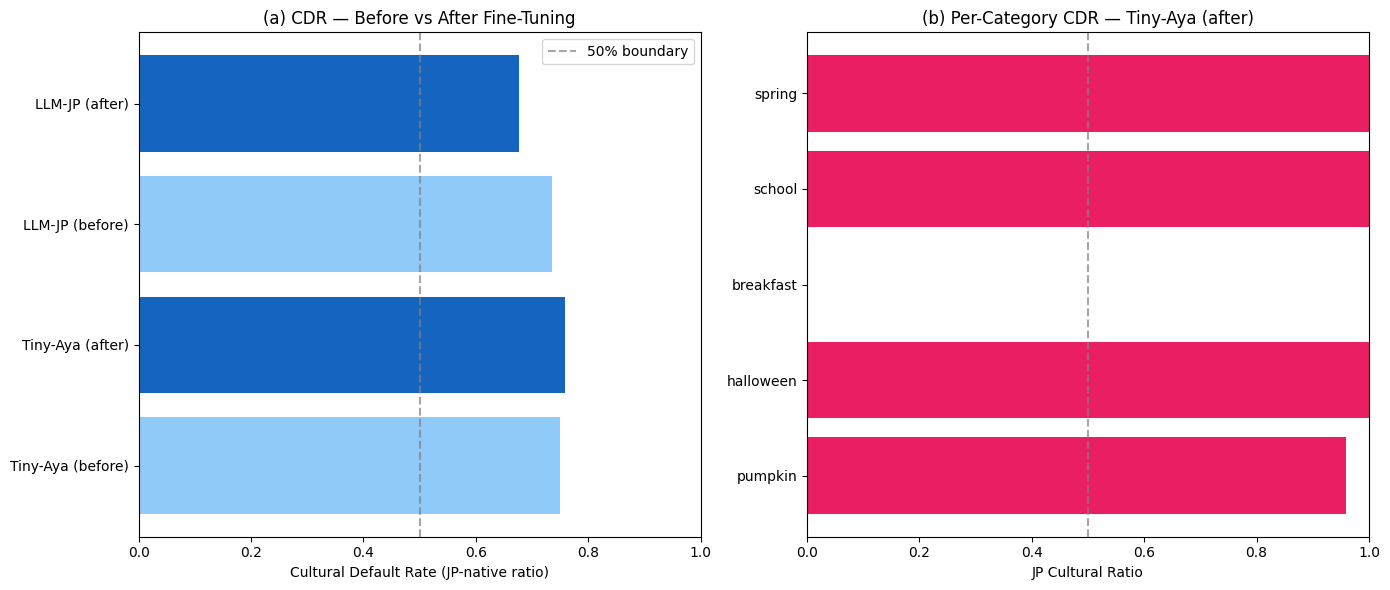

Saved: fig4_cultural_default_rate.png


In [16]:
#FIGURE 4: Cultural Default Rate — Before vs After Fine-Tuning

if cultural_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    #1: CDR bar chart
    models = list(cultural_results.keys())
    cdrs = [cultural_results[m][1] for m in models]  # index 1 = cdr value
    colors = ['#90CAF9' if 'before' in m else '#1565C0' for m in models]
    
    axes[0].barh(models, cdrs, color=colors)
    axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='50% boundary')
    axes[0].set_xlabel('Cultural Default Rate (JP-native ratio)')
    axes[0].set_title('(a) CDR — Before vs After Fine-Tuning')
    axes[0].set_xlim(0, 1)
    axes[0].legend()
    
    #2: Per-category breakdown
    after_models = [k for k in cultural_results if 'after' in k]
    if after_models:
        best = after_models[0]
        detail_df = cultural_results[best][0]  # index 0 = detail dataframe
        categories = [pid for pid in CULTURAL_MARKERS if pid in detail_df['prompt_id'].values]
        ratios = []
        for pid in categories:
            subset = detail_df[detail_df['prompt_id'] == pid]
            jp = subset['japanese_hits'].sum()
            w = subset['western_hits'].sum()
            ratios.append(jp / (jp + w) if (jp + w) > 0 else 0.5)
        
        bar_colors = ['#E91E63' if r > 0.5 else '#FF9800' for r in ratios]
        axes[1].barh(categories, ratios, color=bar_colors)
        axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
        axes[1].set_xlabel('JP Cultural Ratio')
        axes[1].set_title(f'(b) Per-Category CDR — {best}')
        axes[1].set_xlim(0, 1)
    
    plt.tight_layout()
    #plt.savefig('figures/fig4_cultural_default_rate.pdf', bbox_inches='tight', dpi=150)
    plt.savefig('figures/fig4_cultural_default_rate.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: fig4_cultural_default_rate.png")
else:
    print("No cultural probing data available")


## 6. Cultural Showcase — Qualitative Western vs Eastern Analysis

In [17]:
#CULTURAL SHOWCASE, Before vs After Fine-Tuning comparison

def analyze_showcase(df_before, df_after, model_name):
    #Compare cultural markers in showcase stories before and after fine-tuning
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    
    for setting in ['western', 'eastern']:
        print(f"\n  [{setting.upper()} setting]")
        
        for label, df in [('BEFORE FT', df_before), ('AFTER FT', df_after)]:
            if df is None:
                print(f"    {label}: No data")
                continue
            row = df[df['setting'] == setting]
            if len(row) == 0:
                continue
            story = row.iloc[0]['story']
            
            total_w, total_j = 0, 0
            for markers in CULTURAL_MARKERS.values():
                w, j = score_cultural_markers(story, markers)
                total_w += w
                total_j += j
            
            print(f"    {label}: {len(story)} chars | JP markers: {total_j} | W markers: {total_w}")
            print(f"    Preview: {story[:150]}...")

analyze_showcase(tiny_aya_show_before, tiny_aya_show_after, "Tiny-Aya (CohereLabs/tiny-aya-water)")
analyze_showcase(llm_jp_show_before, llm_jp_show_after, "LLM-JP (llm-jp-3-3.7b-instruct)")



  Tiny-Aya (CohereLabs/tiny-aya-water)

  [WESTERN setting]
    BEFORE FT: 1442 chars | JP markers: 1 | W markers: 3
    Preview: タイトル: 「ハロー・アンド・グッドバイ」

舞台設定: アメリカ合衆国東海岸にある小さな町「リトルフォールズ」。美しい紅葉の森と川に囲まれたこの町は、静かで穏やかだが、時折奇妙なことが起こることで知られている。人口は約500人で、住民たちは皆顔見知りであり、まるで一つの大きな家族のように絆が強い。...
    AFTER FT: 2357 chars | JP markers: 0 | W markers: 3
    Preview: **タイトル: 「カボチャの光と鐘の歌」**

**プロローグ: ハロウィンの夜**

秋の風が冷たく吹き抜けるアメリカの田舎町、リトル・グリーン・バレーでは、ハロウィンの夜が迫っていた。夕暮れの空には、オレンジ色のかぼちゃのランタンを装飾した家々が広がり、街全体が魔法の世界へと変貌していた。主人公...

  [EASTERN setting]
    BEFORE FT: 1432 chars | JP markers: 3 | W markers: 0
    Preview: 東京郊外から離れた山間の小さな町であるこの場所は、「田舎」とは呼べないほど整備された道路も店も多いが、それでもどこか懐かしい風情を持つ。夏の昼間は蝉の声に混じってラジオ体操の歌が聞こえてくるし、夕方には近所の犬たちがワンワンと遠吠えして一日の終わりを知らせてくれる。そんな静かな町で、今年もまたお盆が...
    AFTER FT: 1949 chars | JP markers: 8 | W markers: 1
    Preview: **タイトル：月の光と古き良き祭り**

**第一章：祖母の家での静寂**
8月の日本、中部地方の小さな村・木ノ成（きのはた）では、汗ばむ夏の空気の中、お盆の準備が進む。花の祖母の家は古びた段差があり、庭の石灯籠が薄暗い夜に揺れる。7時過ぎ、花と父が古着を整理していると、祖母が「明日は夏祭りの準備だ...

  LLM-JP (llm-jp-3-3.7b

## 7. High-Frequency Word Analysis

Compare the most frequent content words across models to identify
culturally-distinctive vocabulary patterns.

In [18]:
#JAPANESE TOP WORDS — filter stop words and genre tags

JP_STOP = set('のにはをがでとだもたからまれるいてさしな、。「」（）・\n ')
EN_BLOCK = {
    'https', 'http', 'www', 'com', 'net', 'org',
    'fantasy', 'romance', 'comedy', 'shoujo', 'shounen',
    'slice', 'life', 'action', 'adventure', 'drama', 'sci', 'fi',
    'nl', 'n', 'br', 'the', 'a', 'an', 'is', 'was', 'were',
    'and', 'of', 'to', 'in', 'for', 'it', 'that', 'this',
    'with', 'on', 'at', 'by', 'from', 'or', 'as', 'be', 'are',
    'but', 'not', 'have', 'had', 'has', 'his', 'her', 'he', 'she',
    'they', 'we', 'you', 'my', 'their', 'its', 'i',
}

def get_top_jp_words(texts, n=20):
    words = []
    for t in texts:
        tokens = re.findall(r'[\u3040-\u309F\u30A0-\u30FF\u4E00-\u9FFF]{2,}', str(t))
        words.extend(tokens)
    words = [w for w in words if w not in JP_STOP and len(w) >= 2]
    return Counter(words).most_common(n)

def get_top_en_words(texts, n=20):
    words = []
    for t in texts:
        tokens = re.findall(r'[a-zA-Z]+', str(t).lower())
        words.extend([w for w in tokens if w not in EN_BLOCK and len(w) > 2])
    return Counter(words).most_common(n)

# Japanese models (after FT)
for name, df, col in [
    ("Tiny-Aya (after FT)", tiny_aya_after, 'story'),
    ("LLM-JP (after FT)", llm_jp_after, 'story'),
    ("Rinna (after FT)", rinna_after, 'story_clean'),
]:
    if df is not None and col in df.columns:
        print(f"=== Top Words: {name} ===")
        for w, c in get_top_jp_words(df[col]):
            print(f"  {w}: {c}")
        print()

# English model (after FT)
if en_after is not None:
    print("=== Top Words: Mistral (after FT) ===")
    for w, c in get_top_en_words(en_after['story']):
        print(f"  {w}: {c}")

=== Top Words: Tiny-Aya (after FT) ===
  しかし: 43
  その瞬間: 24
  タイトル: 24
  その時: 20
  でも: 18
  突然: 16
  主人公の: 10
  ねえ: 10
  こんにちは: 10
  振り返ると: 8
  それは: 8
  美咲: 8
  その言葉に: 8
  さあ: 7
  彼女は: 7
  ありがとう: 6
  私は: 6
  最近: 6
  はい: 6
  そして: 6

=== Top Words: LLM-JP (after FT) ===
  しかし: 47
  そして: 33
  でも: 18
  おはよう: 12
  それは: 11
  だが: 10
  こうして: 9
  その瞬間: 9
  みんな: 8
  すると: 7
  突然: 7
  さあ: 6
  彼は: 6
  うん: 6
  振り返ると: 6
  ねえ: 6
  父さん: 5
  その夜: 5
  なぜなら: 5
  ただ: 5

=== Top Words: Rinna (after FT) ===
  女優: 121
  また: 77
  しかし: 32
  そして: 29
  私は: 26
  編集: 24
  それは: 23
  ジェシカ: 20
  ありがとうございます: 15
  では: 14
  この本は: 13
  この物語は: 13
  最後に: 13
  映画: 12
  これは: 12
  この番組は: 11
  この映画は: 11
  ロード・オブ・ザ・リング: 10
  例えば: 10
  全体的に: 10

=== Top Words: Mistral (after FT) ===
  young: 107
  story: 89
  about: 85
  two: 81
  write: 80
  title: 80
  one: 76
  hero: 66
  heart: 64
  library: 64
  nestled: 63
  between: 62
  journey: 57
  eldoria: 56
  students: 56
  upon: 54
  day: 53
  eyes: 52
  ancient: 48
  him: 47


## 8. Summary Results Table (for Final Report)

In [19]:
#=============================================================================
#                       FINAL SUMMARY TABLE: ACL-style
#=============================================================================

print("=" * 80)
print("TABLE 1: Cross-Lingual Comparison of Fine-Tuned Fiction Models")
print("=" * 80)

header = f"{'Metric':<25} "
for model in results:
    header += f"{model:<22} "
print(header)
print("-" * 80)

# Key metrics to report
report_metrics = ['Avg Char Count', 'Char TTR', 'Avg Repetition', 'Char Entropy', 'Avg Sentence Len', 'N Stories']
for metric in report_metrics:
    row = f"{metric:<25} "
    for model in results:
        val = results[model].get(metric, 'N/A')
        if isinstance(val, float):
            row += f"{val:<22.4f} "
        else:
            row += f"{str(val):<22} "
    print(row)


print()

if sentiment_results:
    print(f"{'Sentiment Variance':<25} ", end='')
    for model in results:
        key = model.replace(' (before FT)', ' (JP)').replace(' (after FT)', ' (JP)').replace(' (FT)', ' (JP)')
        if key in sentiment_results:
            print(f"{sentiment_results[key]['var']:<22.4f} ", end='')
        else:
            print(f"{'—':<22} ", end='')
    print()

print("=" * 80)

TABLE 1: Cross-Lingual Comparison of Fine-Tuned Fiction Models
Metric                    Rinna (before)         Rinna (after)          Tiny-Aya (before)      Tiny-Aya (after)       LLM-JP (before)        LLM-JP (after)         Mistral (before)       Mistral (after)        
--------------------------------------------------------------------------------
Avg Char Count            163.3550               636.5250               413.6000               487.5300               406.3700               481.7400               1104.1000              1116.7000              
Char TTR                  0.0216                 0.0198                 0.0314                 0.0292                 0.0313                 0.0278                 0.0030                 0.0008                 
Avg Repetition            0.0387                 0.2086                 0.0000                 0.0241                 0.0000                 0.0000                 0.3120                 0.3461                 
Char Entropy

## 9. Narrative Structure — Kishōtenketsu Arc Analysis

Kishōtenketsu is a four-act narrative structure common in East Asian storytelling:
1. **Ki (起)** — Introduction
2. **Shō (承)** — Development
3. **Ten (転)** — Twist / Unexpected turn
4. **Ketsu (結)** — Conclusion

Unlike Western three-act structure (setup → conflict → resolution), kishōtenketsu
does not require conflict as a driver. We test whether Japanese-trained models produce
sentiment arcs that differ from the Western conflict-driven pattern.

We split each story into quartiles and measure sentiment per quartile using the
multilingual BERT model.

In [20]:
#KISHŌTENKETSU ARC ANALYSIS

def sentiment_arc(text, n_segments=4):
    #Split text into n segments and return sentiment score per segment
    text = str(text).strip()
    if not text:
        return [0] * n_segments
    
    seg_len = max(1, len(text) // n_segments)
    segments = [text[i*seg_len : (i+1)*seg_len] for i in range(n_segments)]
    #Last segment gets any remainder
    segments[-1] = text[(n_segments-1)*seg_len:]
    
    scores = []
    for seg in segments:
        seg_truncated = seg[:512]
        if not seg_truncated.strip():
            scores.append(3)
            continue
        try:
            result = sentiment_pipeline(seg_truncated, truncation=True, max_length=512)
            scores.append(int(result[0]['label'].split()[0]))
        except:
            scores.append(3)
    return scores

def compute_arc_stats(df, story_col, label, max_stories=50):
    #Compute average sentiment arc for a corpus
    if df is None:
        return None
    stories = df[story_col].dropna().head(max_stories)
    arcs = [sentiment_arc(s) for s in stories]
    avg_arc = np.mean(arcs, axis=0)
    std_arc = np.std(arcs, axis=0)
    
    #Measure arc variance
    arc_range = np.mean([max(a) - min(a) for a in arcs])
    
    print(f"  {label}: arc={[f'{v:.2f}' for v in avg_arc]}, range={arc_range:.2f}")
    return avg_arc, std_arc, arc_range

print("Computing narrative arcs (this may take a minute)...\n")
arc_results = {}

for name, df, col in [
    ('Tiny-Aya (after)', tiny_aya_after, 'story'),
    ('Tiny-Aya (before)', tiny_aya_before, 'story'),
    ('LLM-JP (after)', llm_jp_after, 'story'),
    ('Rinna (after)', rinna_after, 'story_clean'),
    ('Mistral (after)', en_after, 'story'),
]:
    if df is not None and col in df.columns:
        result = compute_arc_stats(df, col, name)
        if result is not None:
            arc_results[name] = result

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Computing narrative arcs (this may take a minute)...

  Tiny-Aya (after): arc=['3.72', '3.26', '3.30', '3.20'], range=1.92
  Tiny-Aya (before): arc=['4.06', '3.84', '3.92', '3.84'], range=1.52
  LLM-JP (after): arc=['3.86', '3.58', '3.60', '3.78'], range=2.00
  Rinna (after): arc=['4.08', '4.06', '3.92', '3.80'], range=1.48
  Mistral (after): arc=['3.98', '3.94', '3.82', '3.66'], range=1.48
